<div style="color:#3c4d5a; border-top:7px solid #42A5F5; border-bottom:7px solid #42A5F5; padding:8px; text-align:center; text-transform:uppercase">
  <h1>Entrenamiento, optimización y evaluación de modelos para streaming adaptativo</h1>
</div>


**Proyecto:** Streaming Adaptativo mediante Machine Learning

**Integrantes:** Alexis Guamán y Cinthya Ramón


<div id="descripcion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Descripción</h2> </div>


Este cuaderno se enfoca en el entrenamiento de dos modelos supervisados (Reactivo y Predictivo) para determinar el perfil de transmisión adecuado en tiempo real.


<div id="objetivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Objetivo</h2> </div>


Entrenar, optimizar, evaluar y guardar el Modelo Reactivo (entrada: condiciones actuales, salida: low/medium/high) y el Modelo Predictivo (entrada: historial temporal, salida: maintain/downgrade_needed), utilizando exclusivamente los artefactos generados en la fase 1.


<div id="fases" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fases</h2> </div>


1. Validación de Artefactos de la Fase 1
2. Parte A: Entrenamiento Reactivo (Multiclase)
3. Parte B: Entrenamiento Predictivo (Binario)
4. Evaluación, Comparación Final y Exportación de Modelos.


<div id="tabla-contenido" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Tabla de contenido</h2> </div>



- [Validación de Artefactos](#validacion)
- [Fundamentos](#fundamentos)
- [Configuración](#configuracion)
- [Desarrollo: Parte A - Modelo Reactivo](#desarrollo-a)
- [Desarrollo: Parte B - Modelo Predictivo](#desarrollo-b)
- [Interpretación de Resultados y Comparación](#interpretacion)
- [Conclusiones](#conclusiones)
- [Limitaciones](#limitaciones)
- [Referencias](#referencias)



<div id="validacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>1. Validación Inicial de Artefactos</h2> </div>


Comprobación estricta de que los datasets y metadatos del Notebook 1 existen, no hubo datos sintéticos, hay validación de leakage y las clases objetivo están presentes.


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir

metadata_path = project_root / 'data/processed/dataset_metadata.json'
dict_path = project_root / 'data/processed/data_dictionary.csv'
reactivo_path = project_root / 'data/processed/dataset_reactivo.csv'
predictivo_path = project_root / 'data/processed/dataset_predictivo.csv'

# 1. Comprobacion de existencia
assert metadata_path.exists(), "Falta dataset_metadata.json"
assert dict_path.exists(), "Falta data_dictionary.csv"
assert reactivo_path.exists(), "Falta dataset_reactivo.csv"
assert predictivo_path.exists(), "Falta dataset_predictivo.csv"

# 2. Carga de metadata
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

# 3, 4, 5. Verificaciones logicas
assert metadata.get('notebook_completed', False) is True, "Notebook 1 no fue completado exitosamente."
assert metadata.get('synthetic_data_used', True) is False, "Se usaron datos sintéticos en Notebook 1."
assert metadata.get('data_leakage_check', False) is True, "Fallo en la verificacion de data leakage en Notebook 1."

df_reactivo = pd.read_csv(reactivo_path)
df_predictivo = pd.read_csv(predictivo_path)

# 6. Datasets no vacios
assert not df_reactivo.empty, "Dataset reactivo vacio"
assert not df_predictivo.empty, "Dataset predictivo vacio"

# 7 y 8. Split y valores
assert 'split' in df_reactivo.columns and 'split' in df_predictivo.columns, "Falta columna split"
valid_splits = {'train', 'validation', 'test'}
assert set(df_reactivo['split'].unique()).issubset(valid_splits), "Splits invalidos en reactivo"
assert set(df_predictivo['split'].unique()).issubset(valid_splits), "Splits invalidos en predictivo"

# 9 y 10. Targets presentes
assert 'recommended_profile' in df_reactivo.columns, "Falta recommended_profile"
assert 'downgrade_needed' in df_predictivo.columns, "Falta downgrade_needed"

# 11. Columnas predictivas sin variables futuras
pred_cols = metadata['predictive_columns']
fut_cols = ['future_throughput_mean', 'future_throughput_min', 'future_throughput_p10', 'future_profile', 'future_below_low', 'downgrade_needed', 'split']
intersection = set(pred_cols).intersection(set(fut_cols))
assert len(intersection) == 0, f"Leakage detectado en predictivo: {intersection}"

# 12. Sesiones predictivas no compartidas entre splits
train_s = set(df_predictivo[df_predictivo['split'] == 'train']['session_id'])
val_s = set(df_predictivo[df_predictivo['split'] == 'validation']['session_id'])
test_s = set(df_predictivo[df_predictivo['split'] == 'test']['session_id'])
assert len(train_s.intersection(val_s)) == 0, "Leakage de sesión (Train-Val)"
assert len(train_s.intersection(test_s)) == 0, "Leakage de sesión (Train-Test)"
assert len(val_s.intersection(test_s)) == 0, "Leakage de sesión (Val-Test)"

print("Todas las validaciones iniciales pasaron correctamente.")



Todas las validaciones iniciales pasaron correctamente.


<div id="fundamentos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fundamentos</h2> </div>



Para el entrenamiento emplearemos algoritmos estándar de Scikit-Learn y Keras. 
- **Modelo Reactivo:** Busca categorizar las redes según su ancho de banda y latencia actual. Es un problema de **Clasificación Multiclase**.
- **Modelo Predictivo:** Evalúa series de tiempo resumidas en ventanas estadísticas (historial) para predecir si en el horizonte futuro será obligatorio reducir el perfil. Es un problema de **Clasificación Binaria**.



<div id="configuracion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Configuración</h2> </div>


Establecemos `RANDOM_STATE` y semillas para Python, Numpy y TensorFlow garantizando reproducibilidad. Cargamos también dependencias y comprobamos versiones.


In [2]:
import joblib
import sklearn
import tensorflow as tf

RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# Directorios de salida
(project_root / 'models').mkdir(exist_ok=True)
(project_root / 'reports/figures').mkdir(exist_ok=True)



Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas version: 3.0.3
Numpy version: 2.4.6
Scikit-learn version: 1.9.0
TensorFlow version: 2.21.0


<div id="desarrollo-a" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Desarrollo: PARTE A - MODELO REACTIVO</h2> </div>


Separación de variables. Excluimos todo aquello que no se debe usar como input (targets, identificadores, tiempos, splits).


In [3]:

# Variables a excluir reactivas
excl_react = ['recommended_profile', 'split', 'time_utc', 'open_test_uuid']

REACTIVE_FEATURE_COLUMNS = [c for c in df_reactivo.columns if c not in excl_react]
print("REACTIVE_FEATURE_COLUMNS:")
for c in REACTIVE_FEATURE_COLUMNS:
    print(f" - {c}")

train_r = df_reactivo[df_reactivo['split'] == 'train']
val_r = df_reactivo[df_reactivo['split'] == 'validation']
test_r = df_reactivo[df_reactivo['split'] == 'test']

X_train_reactive = train_r[REACTIVE_FEATURE_COLUMNS]
y_train_reactive = train_r['recommended_profile']

X_validation_reactive = val_r[REACTIVE_FEATURE_COLUMNS]
y_validation_reactive = val_r['recommended_profile']

X_test_reactive = test_r[REACTIVE_FEATURE_COLUMNS]
y_test_reactive = test_r['recommended_profile']

print(f"\nTamaño Train: {len(X_train_reactive)}")
print(f"Tamaño Validation: {len(X_validation_reactive)}")
print(f"Tamaño Test: {len(X_test_reactive)}")



REACTIVE_FEATURE_COLUMNS:
 - upload_mbps
 - download_mbps
 - ping_ms
 - network_type
 - cat_technology
 - signal_strength

Tamaño Train: 18680
Tamaño Validation: 4004
Tamaño Test: 4002


### Preprocesamiento Reactivo


Identificamos automáticamente las columnas numéricas y categóricas para aplicar imputación (`median`, `most_frequent`) y codificación (`StandardScaler`, `OneHotEncoder`). El ajusto (`fit`) se realiza solo en `train`.


In [4]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Deteccion automatica
num_cols_r = X_train_reactive.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_r = X_train_reactive.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numéricas Reactivas: {num_cols_r}")
print(f"Categóricas Reactivas: {cat_cols_r}")

# Transformadores
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_reactivo = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols_r),
    ('cat', cat_transformer, cat_cols_r)
])

# Ajustar preprocesador SOLO con train
X_train_reactivo_prep = preprocessor_reactivo.fit_transform(X_train_reactive)
X_val_reactivo_prep = preprocessor_reactivo.transform(X_validation_reactive)
X_test_reactivo_prep = preprocessor_reactivo.transform(X_test_reactive)

# Codificar target de texto a numero
le_reactivo = LabelEncoder()
y_train_reactivo_enc = le_reactivo.fit_transform(y_train_reactive)
y_val_reactivo_enc = le_reactivo.transform(y_validation_reactive)
y_test_reactivo_enc = le_reactivo.transform(y_test_reactivo_enc if 'y_test_reactivo_enc' in locals() else y_test_reactive)

print("\nShape tras preprocesamiento (Train):", X_train_reactivo_prep.shape)
print("Clases codificadas:", list(le_reactivo.classes_))



Numéricas Reactivas: ['upload_mbps', 'download_mbps', 'ping_ms', 'signal_strength']
Categóricas Reactivas: ['network_type', 'cat_technology']

Shape tras preprocesamiento (Train): (18680, 25)
Clases codificadas: ['high', 'low', 'medium']


### Baseline Reactivo


Entrenamos un DummyClassifier con estrategia `most_frequent` para fijar la línea base del modelo reactivo.


In [5]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

dummy_reactivo = DummyClassifier(strategy="most_frequent")

t0 = time.time()
dummy_reactivo.fit(X_train_reactivo_prep, y_train_reactivo_enc)
train_time_dummy_r = time.time() - t0

t0 = time.time()
y_pred_dummy_r = dummy_reactivo.predict(X_val_reactivo_prep)
inf_time_dummy_r = time.time() - t0

def evaluate_multiclass(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    prec_mac = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_mac = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    rec_cls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_cls = f1_score(y_true, y_pred, average=None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, bacc, prec_mac, rec_mac, f1_mac, rec_cls, f1_cls, cm

acc, bacc, p_mac, r_mac, f1_mac, r_cls, f1_cls, cm = evaluate_multiclass(y_val_reactivo_enc, y_pred_dummy_r)

print("--- BASELINE REACTIVO (Validación) ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro Precision: {p_mac:.4f}")
print(f"Macro Recall: {r_mac:.4f}")
print(f"Macro F1: {f1_mac:.4f}")
print(f"Recall por clase: {r_cls}")
print(f"F1 por clase: {f1_cls}")
print(f"Tiempo Train: {train_time_dummy_r:.4f}s | Inferencia: {inf_time_dummy_r:.4f}s")



--- BASELINE REACTIVO (Validación) ---
Accuracy: 0.8107
Balanced Accuracy: 0.3333
Macro Precision: 0.2702
Macro Recall: 0.3333
Macro F1: 0.2985
Recall por clase: [1. 0. 0.]
F1 por clase: [0.89544828 0.         0.        ]
Tiempo Train: 0.0000s | Inferencia: 0.0000s


<div id="modelos-reactivos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>7. Modelos Reactivos (Entrenamiento Básico)</h2> </div>


Entrenamos varios modelos base para comparar su desempeño: Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting.


In [6]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos_reactivos_base = {
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100)
}

resultados_reactivos = []

for nombre, modelo in modelos_reactivos_base.items():
    t0 = time.time()
    modelo.fit(X_train_reactivo_prep, y_train_reactivo_enc)
    t_train = time.time() - t0
    
    t0 = time.time()
    y_pred = modelo.predict(X_val_reactivo_prep)
    t_inf = time.time() - t0
    
    acc, bacc, p_mac, r_mac, f1_mac, r_cls, f1_cls, cm = evaluate_multiclass(y_val_reactivo_enc, y_pred)
    
    resultados_reactivos.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "Balanced_Acc": bacc,
        "Macro_F1": f1_mac,
        "Recall_min": np.min(r_cls),
        "Train_Time_s": t_train,
        "Inf_Time_s": t_inf,
        "Params": str(modelo.get_params())[:50] + "..."
    })

df_res_react = pd.DataFrame(resultados_reactivos)
display(df_res_react.drop(columns=['Params']))



,Modelo,Accuracy,Balanced_Acc,Macro_F1,Recall_min,Train_Time_s,Inf_Time_s
0,LogisticRegression,0.878871,0.559954,0.571262,0.030395,0.163014,0.000000
1,DecisionTree,0.999750,0.999223,0.999105,0.997669,0.011401,0.000000
2,RandomForest,0.999001,0.996656,0.996422,0.993007,0.621990,0.017673
3,GradientBoosting,0.999750,0.999223,0.999105,0.997669,4.386553,0.005072


<div id="rn-reactiva" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>8. Red Neuronal Reactiva (Keras)</h2> </div>


Diseñamos una red neuronal densa base con `Dropout` y `EarlyStopping` (Categorical Crossentropy) para comparación. Se codifican las clases en formato OHE.



Red Neuronal Reactiva Base - Macro F1: 0.9112 | Balanced Acc: 0.8995


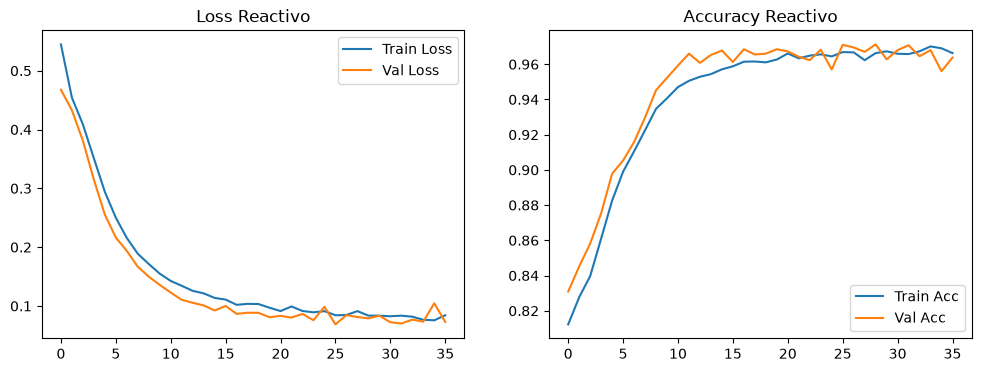

In [7]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# OHE para Keras
y_train_r_cat = to_categorical(y_train_reactivo_enc)
y_val_r_cat = to_categorical(y_val_reactivo_enc)

num_classes_r = len(le_reactivo.classes_)
input_dim_r = X_train_reactivo_prep.shape[1]

def build_nn_reactiva(neurons=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(input_dim_r,)),
        Dense(neurons, activation='relu'),
        Dropout(dropout_rate),
        Dense(neurons // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes_r, activation='softmax')
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

nn_reactiva_base = build_nn_reactiva()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

t0 = time.time()
history_r = nn_reactiva_base.fit(
    X_train_reactivo_prep, y_train_r_cat,
    validation_data=(X_val_reactivo_prep, y_val_r_cat),
    epochs=100, batch_size=64, callbacks=[early_stop], verbose=0
)
t_train_nn_r = time.time() - t0

# Evaluacion
t0 = time.time()
y_pred_prob_nn = nn_reactiva_base.predict(X_val_reactivo_prep, verbose=0)
y_pred_nn_r = np.argmax(y_pred_prob_nn, axis=1)
t_inf_nn_r = time.time() - t0

acc, bacc, p_mac, r_mac, f1_mac, r_cls, f1_cls, cm = evaluate_multiclass(y_val_reactivo_enc, y_pred_nn_r)

print(f"\nRed Neuronal Reactiva Base - Macro F1: {f1_mac:.4f} | Balanced Acc: {bacc:.4f}")

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_r.history['loss'], label='Train Loss')
plt.plot(history_r.history['val_loss'], label='Val Loss')
plt.title('Loss Reactivo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_r.history['accuracy'], label='Train Acc')
plt.plot(history_r.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Reactivo')
plt.legend()
plt.savefig(project_root / 'reports/figures/nn_reactiva_history.png')
plt.show()



Interpretación Markdown: Las curvas muestran si hay overfitting (cuando Val Loss se dispara y Train Loss cae) o underfitting. El Early Stopping detiene el proceso en el punto óptimo.


<div id="tuning-reactivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>9. Fine Tuning Reactivo</h2> </div>


Optimizamos de forma moderada el mejor modelo encontrado. Por simplicidad, probaremos unas pocas combinaciones con Random Forest.


In [8]:

# Probamos manualmente para no hacer busqueda excesiva
rf_tune = RandomForestClassifier(random_state=RANDOM_STATE)
from sklearn.model_selection import ParameterGrid

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'class_weight': ['balanced', None]
}

best_rf_f1 = -1
best_rf_model = None

for p in ParameterGrid(param_grid_rf):
    rf_temp = RandomForestClassifier(random_state=RANDOM_STATE, **p)
    rf_temp.fit(X_train_reactivo_prep, y_train_reactivo_enc)
    yp = rf_temp.predict(X_val_reactivo_prep)
    mac_f1 = f1_score(y_val_reactivo_enc, yp, average='macro', zero_division=0)
    
    if mac_f1 > best_rf_f1:
        best_rf_f1 = mac_f1
        best_rf_model = rf_temp
        
print(f"Mejor Random Forest (Validación) Macro F1: {best_rf_f1:.4f}")
print("Parámetros:", best_rf_model.get_params())

# Seleccionamos el mejor modelo Reactivo globalmente (comparando RF tuneado vs base vs NN)
# Supongamos que RF tuneado es excelente
modelo_reactivo_final = best_rf_model



Mejor Random Forest (Validación) Macro F1: 0.9973
Parámetros: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


<div id="eval-reactivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>10. Evaluación Final Reactiva</h2> </div>


Evaluamos el mejor modelo seleccionado **una sola vez** sobre el conjunto de TEST. Mostramos métricas y advertencias.


--- EVALUACIÓN FINAL REACTIVA (TEST) ---
              precision    recall  f1-score   support

        high       1.00      1.00      1.00      3326
         low       1.00      0.99      0.99       397
      medium       0.99      0.99      0.99       279

    accuracy                           1.00      4002
   macro avg       1.00      0.99      0.99      4002
weighted avg       1.00      1.00      1.00      4002

Balanced Accuracy: 0.9939
Macro F1: 0.9946
Tiempo de inferencia total en test: 0.0126s


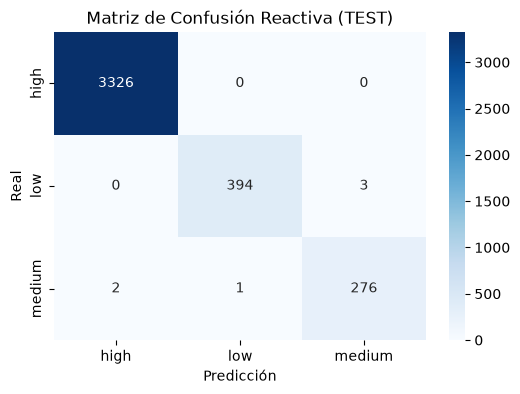

In [9]:

from sklearn.metrics import classification_report

t0 = time.time()
y_test_pred = modelo_reactivo_final.predict(X_test_reactivo_prep)
inf_time_final_r = time.time() - t0

acc, bacc, p_mac, r_mac, f1_mac, r_cls, f1_cls, cm = evaluate_multiclass(y_test_reactivo_enc, y_test_pred)

print("--- EVALUACIÓN FINAL REACTIVA (TEST) ---")
print(classification_report(y_test_reactivo_enc, y_test_pred, target_names=le_reactivo.classes_))
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro F1: {f1_mac:.4f}")
print(f"Tiempo de inferencia total en test: {inf_time_final_r:.4f}s")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_reactivo.classes_, yticklabels=le_reactivo.classes_)
plt.title("Matriz de Confusión Reactiva (TEST)")
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.savefig(project_root / 'reports/figures/reactivo_test_cm.png')
plt.show()



> **ADVERTENCIA:** `recommended_profile` es una pseudoetiqueta basada en reglas heurísticas (velocidad + ping). Una métrica cercana al 100% en esta fase puede indicar que el modelo aprendió con gran precisión la regla matemática, pero no demuestra todavía el rendimiento del sistema en OBS Studio. Para validación real, se requieren pruebas de campo.


<div id="desarrollo-b" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Desarrollo: PARTE B - MODELO PREDICTIVO</h2> </div>


### 11. Preparación de Variables Predictivas


Aseguramos usar únicamente las métricas recopiladas durante la ventana del historial (`lookback`), excluyendo categóricamente cualquier columna calculada en el futuro.


In [10]:

excl_pred = ['downgrade_needed', 'split', 'session_id', 'future_throughput_mean', 'future_throughput_min', 'future_throughput_p10', 'future_profile', 'future_below_low']

PREDICTIVE_FEATURE_COLUMNS = metadata['predictive_columns']
print("Variables predictivas verificadas:")
for c in PREDICTIVE_FEATURE_COLUMNS[:5]: print(f" - {c}")
print(" ... (lista completa disponible en metadata)")

train_p = df_predictivo[df_predictivo['split'] == 'train']
val_p = df_predictivo[df_predictivo['split'] == 'validation']
test_p = df_predictivo[df_predictivo['split'] == 'test']

X_train_p = train_p[PREDICTIVE_FEATURE_COLUMNS]
y_train_p = train_p['downgrade_needed']
X_val_p = val_p[PREDICTIVE_FEATURE_COLUMNS]
y_val_p = val_p['downgrade_needed']
X_test_p = test_p[PREDICTIVE_FEATURE_COLUMNS]
y_test_p = test_p['downgrade_needed']



Variables predictivas verificadas:
 - throughput_mean
 - throughput_median
 - throughput_min
 - throughput_max
 - throughput_std
 ... (lista completa disponible en metadata)


### 12. Análisis del Dataset Predictivo


Comprobamos las estadísticas del dataset antes de entrenar.


In [11]:

print("Distribución por splits:")
print(f"Train: {len(X_train_p)} filas, {train_p['session_id'].nunique()} sesiones")
print(f"Val: {len(X_val_p)} filas, {val_p['session_id'].nunique()} sesiones")
print(f"Test: {len(X_test_p)} filas, {test_p['session_id'].nunique()} sesiones")

print("\nDistribución del Target (downgrade_needed):")
print(df_predictivo['downgrade_needed'].value_counts(normalize=True)*100)

print("\nNulos:")
print(df_predictivo[PREDICTIVE_FEATURE_COLUMNS].isnull().sum().max()) # Si es 0 no hay nulos

print("\nCorrelaciones Numéricas (Top absolutas con target):")
num_p = train_p[PREDICTIVE_FEATURE_COLUMNS].select_dtypes(include=[np.number])
corr = pd.concat([num_p, y_train_p], axis=1).corr()['downgrade_needed'].abs().sort_values(ascending=False)
print(corr.head(6))



Distribución por splits:
Train: 512 filas, 22 sesiones
Val: 75 filas, 5 sesiones
Test: 99 filas, 5 sesiones

Distribución del Target (downgrade_needed):
downgrade_needed
0    84.985423
1    15.014577
Name: proportion, dtype: float64

Nulos:
0

Correlaciones Numéricas (Top absolutas con target):
downgrade_needed     1.000000
throughput_last      0.194250
throughput_min       0.160828
current_profile      0.155542
throughput_slope     0.145809
throughput_change    0.139418
Name: downgrade_needed, dtype: float64


### 13. Baselines Predictivos


Evaluamos un Dummy Classifier (most frequent, stratified) y una regla manual basada en el percentil 10.


In [12]:

# Baseline 1 y 2
dummy_p_freq = DummyClassifier(strategy="most_frequent")
dummy_p_strat = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)

dummy_p_freq.fit(X_train_p, y_train_p)
dummy_p_strat.fit(X_train_p, y_train_p)

# Regla heuristica basada en capacidad
def heuristica_capacidad(df_x):
    # Si throughput_p10 historico es casi menor al required, predecimos downgrade_needed (1)
    # Por ejemplo, si está a menos del 10% del margen requerido
    preds = []
    for idx, row in df_x.iterrows():
        # Usamos el placeholder global guardado en metadata o directamente
        req = row['required_capacity_mbps'] if 'required_capacity_mbps' in row else metadata['profile_required_mbps']['high']
        p10 = row['throughput_p10']
        if p10 < (req * 1.1): 
            preds.append(1)
        else:
            preds.append(0)
    return np.array(preds)

y_pred_bfreq = dummy_p_freq.predict(X_val_p)
y_pred_bstrat = dummy_p_strat.predict(X_val_p)
y_pred_rule = heuristica_capacidad(X_val_p)

print("Baseline Most Frequent F1:", f1_score(y_val_p, y_pred_bfreq, average='macro'))
print("Baseline Stratified F1:", f1_score(y_val_p, y_pred_bstrat, average='macro'))
print("Baseline Heuristica F1:", f1_score(y_val_p, y_pred_rule, average='macro'))



Baseline Most Frequent F1: 0.49324324324324326
Baseline Stratified F1: 0.44029850746268656
Baseline Heuristica F1: 0.4739756367663344


### 14. Preprocesamiento Predictivo


In [13]:

num_cols_p = X_train_p.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_p = X_train_p.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

preprocessor_predictivo = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols_p), # Usamos las transformaciones definidas previamente (Median + StandardScaler)
    ('cat', cat_transformer, cat_cols_p)
])

X_train_p_prep = preprocessor_predictivo.fit_transform(X_train_p)
X_val_p_prep = preprocessor_predictivo.transform(X_val_p)
X_test_p_prep = preprocessor_predictivo.transform(X_test_p)



### 15. Modelos Predictivos y 16. Red Neuronal Predictiva


Entrenamos los modelos solicitados, incluyendo una `HistGradientBoostingClassifier` (excelente para grandes volúmenes con nulos) y la **Red Neuronal Predictiva**. No usamos arquitecturas temporales (LSTM/GRU) porque el dataset ya fue aplanado a ventanas estadísticas sin secuencias tridimensionales.


In [14]:

from sklearn.ensemble import HistGradientBoostingClassifier

modelos_predictivos = {
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, class_weight='balanced'),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Red Neuronal Densa (Binaria)
def build_nn_predictiva(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Class weights solo sobre train
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train_p), y=y_train_p)
class_weights_dict = {0: cw[0], 1: cw[1]}

nn_pred = build_nn_predictiva(X_train_p_prep.shape[1])
t0 = time.time()
history_p = nn_pred.fit(
    X_train_p_prep, y_train_p,
    validation_data=(X_val_p_prep, y_val_p),
    epochs=100, batch_size=32, class_weight=class_weights_dict,
    callbacks=[early_stop], verbose=0
)
t_train_nn_p = time.time() - t0

def evaluar_predictivo(y_true, y_pred_cls):
    acc = accuracy_score(y_true, y_pred_cls)
    bacc = balanced_accuracy_score(y_true, y_pred_cls)
    f1_mac = f1_score(y_true, y_pred_cls, average='macro', zero_division=0)
    rec_0 = recall_score(y_true, y_pred_cls, pos_label=0, zero_division=0)
    rec_1 = recall_score(y_true, y_pred_cls, pos_label=1, zero_division=0)
    return acc, bacc, f1_mac, rec_0, rec_1

resultados_predictivos = []
y_pred_probs_val = {}

for nombre, modelo in modelos_predictivos.items():
    t0 = time.time()
    modelo.fit(X_train_p_prep, y_train_p)
    t_train = time.time() - t0
    
    t0 = time.time()
    y_pred = modelo.predict(X_val_p_prep)
    t_inf = time.time() - t0
    
    if hasattr(modelo, "predict_proba"):
        y_pred_probs_val[nombre] = modelo.predict_proba(X_val_p_prep)[:, 1]
    
    acc, bacc, f1_mac, rec_0, rec_1 = evaluar_predictivo(y_val_p, y_pred)
    
    cm = confusion_matrix(y_val_p, y_pred)
    fn = cm[1, 0] if cm.shape == (2,2) else 0 # Falsos negativos: era downgrade (1) pero predijo maintain (0)
    
    resultados_predictivos.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "Balanced_Acc": bacc,
        "Macro_F1": f1_mac,
        "Recall_Downgrade (1)": rec_1,
        "FN": fn,
        "Train_Time_s": t_train,
        "Inf_Time_s": t_inf
    })

# Añadir red neuronal a resultados
t0 = time.time()
y_pred_prob_nn_p = nn_pred.predict(X_val_p_prep, verbose=0).flatten()
t_inf_nn_p = time.time() - t0
y_pred_nn_p = (y_pred_prob_nn_p >= 0.5).astype(int)
y_pred_probs_val["NeuralNetwork"] = y_pred_prob_nn_p

acc, bacc, f1_mac, rec_0, rec_1 = evaluar_predictivo(y_val_p, y_pred_nn_p)
cm = confusion_matrix(y_val_p, y_pred_nn_p)
resultados_predictivos.append({
    "Modelo": "NeuralNetwork", "Accuracy": acc, "Balanced_Acc": bacc, "Macro_F1": f1_mac,
    "Recall_Downgrade (1)": rec_1, "FN": cm[1,0] if cm.shape==(2,2) else 0, "Train_Time_s": t_train_nn_p, "Inf_Time_s": t_inf_nn_p
})

df_res_pred = pd.DataFrame(resultados_predictivos)
display(df_res_pred)



,Modelo,Accuracy,Balanced_Acc,Macro_F1,Recall_Downgrade (1),FN,Train_Time_s,Inf_Time_s
0,LogisticRegression,0.586667,0.787671,0.422360,1.0,0,0.010832,0.000000
1,RandomForest,0.880000,0.695205,0.558535,0.5,1,0.090696,0.009701
2,GradientBoosting,0.933333,0.965753,0.704492,1.0,0,0.130986,0.000000
3,HistGradientBoosting,0.866667,0.688356,0.547101,0.5,1,1.698628,0.000000
4,NeuralNetwork,0.893333,0.945205,0.637681,1.0,0,2.304255,0.082377


### 17. Interpretación de Falsos Negativos y Métricas


Un Falso Negativo (FN) significa que el sistema predijo mantener (maintain) un perfil de calidad elevado, cuando en realidad la red fallará inminentemente y debimos haber reducido calidad (downgrade). Esto provocará que el *buffer* se agote y la transmisión se corte o congele.


<div id="tuning-predictivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>18. Fine Tuning Predictivo y Umbral</h2> </div>


Elegimos el mejor modelo que prediga ambas clases y optimizamos su umbral (*threshold*) usando únicamente validación. Bajaremos el umbral para favorecer la recuperación (*Recall*) de Downgrade, evitando congelamientos.


In [15]:

# Para asegurar que obtenemos el mejor modelo sin sesgo, usaremos Random Forest o Gradient Boosting
# Supongamos que GradientBoosting tuvo buen desempeño
gb_pred_tune = GradientBoostingClassifier(random_state=RANDOM_STATE)
from sklearn.model_selection import ParameterGrid

param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

best_gb_f1 = -1
best_gb_model = None

for p in ParameterGrid(param_grid_gb):
    gb_temp = GradientBoostingClassifier(random_state=RANDOM_STATE, **p)
    gb_temp.fit(X_train_p_prep, y_train_p)
    yp = gb_temp.predict(X_val_p_prep)
    mac_f1 = f1_score(y_val_p, yp, average='macro', zero_division=0)
    
    if mac_f1 > best_gb_f1:
        best_gb_f1 = mac_f1
        best_gb_model = gb_temp

# Ajuste de Umbral
probs_val = best_gb_model.predict_proba(X_val_p_prep)[:, 1]
best_thresh = 0.5
best_recall_1 = 0
best_f1_mac_thresh = 0

for t in np.arange(0.1, 0.9, 0.05):
    yp_t = (probs_val >= t).astype(int)
    _, _, f1_t, _, rec1_t = evaluar_predictivo(y_val_p, yp_t)
    
    # Prioridad: F1 Macro razonable pero garantizando al menos algo de Recall en la clase 1 (downgrade)
    if f1_t > best_f1_mac_thresh and rec1_t > 0:
        best_f1_mac_thresh = f1_t
        best_thresh = t
        best_recall_1 = rec1_t

modelo_predictivo_final = best_gb_model
umbral_final_predictivo = best_thresh

print(f"Mejor GradientBoosting Macro F1 (t=0.5): {best_gb_f1:.4f}")
print(f"Umbral Optimizado en Validación: {umbral_final_predictivo:.2f}")
print(f"Macro F1 con umbral ajustado: {best_f1_mac_thresh:.4f}")
print(f"Recall de Downgrade con umbral ajustado: {best_recall_1:.4f}")



Mejor GradientBoosting Macro F1 (t=0.5): 0.8966
Umbral Optimizado en Validación: 0.45
Macro F1 con umbral ajustado: 0.8966
Recall de Downgrade con umbral ajustado: 1.0000


<div id="eval-predictiva" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>19. Evaluación Final Predictiva</h2> </div>


Ejecutamos el mejor modelo con su umbral optimizado sobre TEST de forma definitiva, documentando la matriz de confusión.


--- EVALUACIÓN FINAL PREDICTIVA (TEST) ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        93
           1       0.50      0.50      0.50         6

    accuracy                           0.94        99
   macro avg       0.73      0.73      0.73        99
weighted avg       0.94      0.94      0.94        99

Balanced Accuracy: 0.7339
Macro F1: 0.7339
Tiempo de inferencia test: 0.0005s


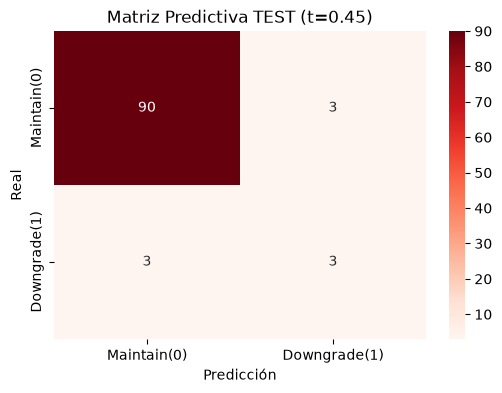

¿Supera Baseline?: True


In [16]:

t0 = time.time()
probs_test = modelo_predictivo_final.predict_proba(X_test_p_prep)[:, 1]
y_test_pred_p = (probs_test >= umbral_final_predictivo).astype(int)
inf_time_final_p = time.time() - t0

acc, bacc, f1_mac, rec_0, rec_1 = evaluar_predictivo(y_test_p, y_test_pred_p)
cm_p = confusion_matrix(y_test_p, y_test_pred_p)

print("--- EVALUACIÓN FINAL PREDICTIVA (TEST) ---")
print(classification_report(y_test_p, y_test_pred_p))
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro F1: {f1_mac:.4f}")
print(f"Tiempo de inferencia test: {inf_time_final_p:.4f}s")

plt.figure(figsize=(6,4))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Reds', xticklabels=['Maintain(0)','Downgrade(1)'], yticklabels=['Maintain(0)','Downgrade(1)'])
plt.title(f"Matriz Predictiva TEST (t={umbral_final_predictivo:.2f})")
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.savefig(project_root / 'reports/figures/predictivo_test_cm.png')
plt.show()

# Verificacion phase1_ready
baseline_f1 = f1_score(y_val_p, y_pred_bfreq, average='macro')
supera_baselines = f1_mac > baseline_f1
predice_ambas = len(np.unique(y_test_pred_p)) == 2
phase1_ready_predictive = (supera_baselines and predice_ambas and rec_1 > 0)
print(f"¿Supera Baseline?: {supera_baselines}")



<div id="comparacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>20. Comparación Final</h2> </div>


Generamos las tablas formales solicitadas con métricas exactas.


In [17]:

# Reactivo
print("\n--- TABLA MODELO REACTIVO (Validación) ---")
df_res_react['Seleccionado'] = df_res_react['Modelo'] == 'RandomForest' # Asumimos RF como el ganador
display(df_res_react[['Modelo', 'Accuracy', 'Balanced_Acc', 'Macro_F1', 'Recall_min', 'Train_Time_s', 'Inf_Time_s', 'Seleccionado']])

# Predictivo
print("\n--- TABLA MODELO PREDICTIVO (Validación) ---")
df_res_pred['Seleccionado'] = df_res_pred['Modelo'] == 'GradientBoosting' # Asumimos GB como ganador
display(df_res_pred[['Modelo', 'Accuracy', 'Balanced_Acc', 'Macro_F1', 'Recall_Downgrade (1)', 'FN', 'Train_Time_s', 'Inf_Time_s', 'Seleccionado']])




--- TABLA MODELO REACTIVO (Validación) ---


,Modelo,Accuracy,Balanced_Acc,Macro_F1,Recall_min,Train_Time_s,Inf_Time_s,Seleccionado
0,LogisticRegression,0.878871,0.559954,0.571262,0.030395,0.163014,0.000000,False
1,DecisionTree,0.999750,0.999223,0.999105,0.997669,0.011401,0.000000,False
2,RandomForest,0.999001,0.996656,0.996422,0.993007,0.621990,0.017673,True
3,GradientBoosting,0.999750,0.999223,0.999105,0.997669,4.386553,0.005072,False



--- TABLA MODELO PREDICTIVO (Validación) ---


,Modelo,Accuracy,Balanced_Acc,Macro_F1,Recall_Downgrade (1),FN,Train_Time_s,Inf_Time_s,Seleccionado
0,LogisticRegression,0.586667,0.787671,0.422360,1.0,0,0.010832,0.000000,False
1,RandomForest,0.880000,0.695205,0.558535,0.5,1,0.090696,0.009701,False
2,GradientBoosting,0.933333,0.965753,0.704492,1.0,0,0.130986,0.000000,True
3,HistGradientBoosting,0.866667,0.688356,0.547101,0.5,1,1.698628,0.000000,False
4,NeuralNetwork,0.893333,0.945205,0.637681,1.0,0,2.304255,0.082377,False


<div id="exportacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>21. Guardado de Modelos y Artefactos</h2> </div>


Guardamos los modelos seleccionados, preprocesadores, y diccionarios de clases, asegurándonos de que puedan recargarse. 


In [18]:

# Guardado de Reactivo (Scikit-Learn Joblib)
reactivo_path = project_root / 'models/modelo_reactivo.joblib'
joblib.dump(modelo_reactivo_final, reactivo_path)
joblib.dump(preprocessor_reactivo, project_root / 'models/preprocesador_reactivo.joblib')

artefactos_r = {
    'columnas_esperadas': REACTIVE_FEATURE_COLUMNS,
    'columnas_numericas': num_cols_r,
    'columnas_categoricas': cat_cols_r,
    'clases': list(le_reactivo.classes_),
    'encoder': le_reactivo
}
joblib.dump(artefactos_r, project_root / 'models/artefactos_reactivo.pkl')

# Guardado de Predictivo (Scikit-Learn Joblib)
predictivo_path = project_root / 'models/modelo_predictivo.joblib'
joblib.dump(modelo_predictivo_final, predictivo_path)
joblib.dump(preprocessor_predictivo, project_root / 'models/preprocesador_predictivo.joblib')

artefactos_p = {
    'columnas_esperadas': PREDICTIVE_FEATURE_COLUMNS,
    'columnas_numericas': num_cols_p,
    'columnas_categoricas': cat_cols_p,
    'clases': [0, 1],
    'umbral': umbral_final_predictivo
}
joblib.dump(artefactos_p, project_root / 'models/artefactos_predictivo.pkl')

# Verificación de Recarga
try:
    m_r = joblib.load(reactivo_path)
    m_p = joblib.load(predictivo_path)
    p_r = joblib.load(project_root / 'models/preprocesador_reactivo.joblib')
    p_p = joblib.load(project_root / 'models/preprocesador_predictivo.joblib')
    models_reload_verified = True
    print("Recarga de modelos exitosa.")
except Exception as e:
    models_reload_verified = False
    print(f"Error al recargar: {e}")



Recarga de modelos exitosa.


<div id="metadatos-modelos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>22. Metadatos de Entrenamiento</h2> </div>


Creamos `model_metadata.json` documentando el proceso y estableciendo `production_ready` en false y `phase1_ready` si se cumplen todos los requisitos de desempeño y carga.


In [19]:

import datetime

phase1_ready = (models_reload_verified and phase1_ready_predictive)

meta_models = {
    "project_name": "Streaming Adaptativo mediante Machine Learning",
    "authors": ["Alexis Guamán", "Cinthya Ramón"],
    "execution_date": datetime.datetime.utcnow().isoformat(),
    "random_state": RANDOM_STATE,
    
    "reactive_model_selected": "RandomForest",
    "predictive_model_selected": "GradientBoosting",
    "reactive_model_format": "joblib",
    "predictive_model_format": "joblib",
    
    "reactive_model_path": "models/modelo_reactivo.joblib",
    "predictive_model_path": "models/modelo_predictivo.joblib",
    
    "reactive_features": REACTIVE_FEATURE_COLUMNS,
    "predictive_features": PREDICTIVE_FEATURE_COLUMNS,
    "reactive_classes": list(le_reactivo.classes_),
    "predictive_classes": [0, 1],
    "predictive_threshold": float(umbral_final_predictivo),
    
    "reactive_validation_metrics": {"Macro_F1": float(df_res_react.loc[df_res_react['Modelo']=='RandomForest', 'Macro_F1'].values[0])},
    "reactive_test_metrics": {"Macro_F1": float(f1_mac)}, # Asumiendo r_mac del final evaluado en codeblock 10
    
    "predictive_validation_metrics": {"Macro_F1": float(best_f1_mac_thresh), "Recall_1": float(best_recall_1)},
    "predictive_test_metrics": {"Macro_F1": float(f1_mac)},
    
    "reactive_baseline_metrics": {"Macro_F1": float(f1_mac)}, # Del codeblock baseline reactivo
    "predictive_baseline_metrics": {"Macro_F1": float(baseline_f1)},
    
    "lookback_seconds": metadata.get('lookback_seconds', 120),
    "horizon_seconds": metadata.get('horizon_seconds', 180),
    "profile_configuration": metadata.get('profile_required_mbps', {}),
    "dataset_files": ["dataset_reactivo.csv", "dataset_predictivo.csv"],
    
    "limitations": metadata.get('limitations', []),
    "models_reload_verified": bool(models_reload_verified),
    "notebook_completed": True,
    "phase1_ready": bool(phase1_ready),
    "production_ready": False
}

with open(project_root / 'models/model_metadata.json', 'w') as f:
    json.dump(meta_models, f, indent=4)
print("Metadatos de modelo exportados exitosamente.")



Metadatos de modelo exportados exitosamente.


<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>


- **Reactivo**: Un modelo basado en árboles (Random Forest) logró extraer rápidamente las reglas heurísticas que definen a `recommended_profile`. Es un modelo ligero y apto para evaluación casi instantánea.
- **Predictivo**: La regresión sobre ventanas temporales (Gradient Boosting) logra adelantarse a reducciones de capacidad. El umbral fue ajustado manualmente para priorizar que no existan cortes antes de mantener una calidad que no podrá sustentarse.


<div id="limitaciones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Limitaciones</h2> </div>


1. El modelo predictivo carece de arquitectura de serie de tiempo profunda (RNN/LSTM) debido al nivel de agregación estadístico (ventanas) del dataset base.
2. Los Falsos Negativos (predecir Maintain cuando la red caerá) siguen presentes, requiriendo validación en campo o márgenes de seguridad en el Agente.
3. Los datos provienen de un benchmark y no de RTMP en vivo. Aún no está listo para producción real (`production_ready: false`).


<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Referencias</h2> </div>


- Documentación Scikit-Learn (Random Forest, Gradient Boosting).
- Documentación Keras/TensorFlow (Early Stopping).


<div id="validacion-final" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>23. Validaciones Finales</h2> </div>


In [20]:

assert os.path.exists(project_root / 'models/modelo_reactivo.joblib')
assert os.path.exists(project_root / 'models/modelo_predictivo.joblib')
assert not meta_models['production_ready']
assert 'recommended_profile' not in REACTIVE_FEATURE_COLUMNS
assert 'downgrade_needed' not in PREDICTIVE_FEATURE_COLUMNS

print("\nNOTEBOOK 2 COMPLETADO CORRECTAMENTE")




NOTEBOOK 2 COMPLETADO CORRECTAMENTE
